In [ ]:
# ============================================
# INSTALL REQUIRED LIBRARIES
# ============================================

!pip install -q pandas openpyxl
!pip install -q nltk spacy gensim pyLDAvis
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 85.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 104.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords

import spacy

from gensim import corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel

import matplotlib.pyplot as plt

import pyLDAvis
import pyLDAvis.gensim_models

nltk.download('stopwords')

ModuleNotFoundError: No module named 'gensim'

In [ ]:
df = pd.read_excel("DatabaseLDA.xlsx")

print(df.head())

print(df.columns)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

                                               Title  \
0  Feasibility assessment of an efficient hydroge...   
1  Study of hydrogen gas production coupled with ...   
2  Ni(OH)2 as Hole Mediator for Visible Light-Ind...   
3  Electronic modulation of nitride/hydroxide het...   
4  Robust and Highly Efficient Electrochemical Hy...   

                                            Abstract  
0  Power to gas is one of the effective pathways ...  
1  Hydrogen gas production coupled with phenol el...  
2  Urea is a small molecule produced in millions ...  
3  The oxidation of urea holds great promise for ...  
4  Hydrazineoxidation-assisted water electrolysis...  
Index(['Title', 'Abstract'], dtype='object')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ============================================
# CREATE DOCUMENT
# ============================================

df["Document"] = (
    df["Title"].fillna("") +
    " " +
    df["Abstract"].fillna("")
)

print(df["Document"].iloc[0])

Feasibility assessment of an efficient hydrogen-freshwater cogeneration system for remote mining area based on solid oxide electrolysis cell Power to gas is one of the effective pathways to levelling out fluctuations of renewable energy, and solid oxide electrolysis cells (SOECs) have attracted more attention owing to high electrolytic efficiency. However, thermal management of electrolysis process is the crucial part to ensuring the efficiency. In this paper, an efficient hydrogen-freshwater cogeneration system based on SOEC and triple-stage flash evaporation is proposed. The SOEC subsystem is employed to convert surplus electricity to hydrogen, and the triple-stage flash evaporation subsystem is established to the cascade utilization of waste heat from the former. Moreover, the mining wastewater can be recycled to produce fresh water in this process. The feasibility assessment of the proposed system is conducted based on the system thermodynamic model. The results indicate that among

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ============================================
# TEXT PREPROCESSING
# ============================================

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))

extra_stopwords = {
    "study",
    "results",
    "method",
    "methods",
    "paper",
    "article",
    "using",
    "used",
    "based",
    "show",
    "shows"
}

stop_words.update(extra_stopwords)

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-z\s]', ' ', text)

    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.is_stop:
            continue

        if token.lemma_ in stop_words:
            continue

        if len(token.lemma_) < 3:
            continue

        tokens.append(token.lemma_)

    return tokens

texts = df["Document"].apply(preprocess)

print(texts.iloc[0][:40])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

['feasibility', 'assessment', 'efficient', 'hydrogen', 'freshwater', 'cogeneration', 'system', 'remote', 'mining', 'area', 'base', 'solid', 'oxide', 'electrolysis', 'cell', 'power', 'gas', 'effective', 'pathway', 'level', 'fluctuation', 'renewable', 'energy', 'solid', 'oxide', 'electrolysis', 'cell', 'soec', 'attract', 'attention', 'owe', 'high', 'electrolytic', 'efficiency', 'thermal', 'management', 'electrolysis', 'process', 'crucial', 'ensure']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ============================================
# DICTIONARY
# ============================================

dictionary = corpora.Dictionary(texts)

dictionary.filter_extremes(
    no_below=3,
    no_above=0.5
)

corpus = [dictionary.doc2bow(text) for text in texts]

print("Number of terms:", len(dictionary))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of terms: 1127


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Se truncaron las últimas líneas 5000 del resultado de transmisión.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime

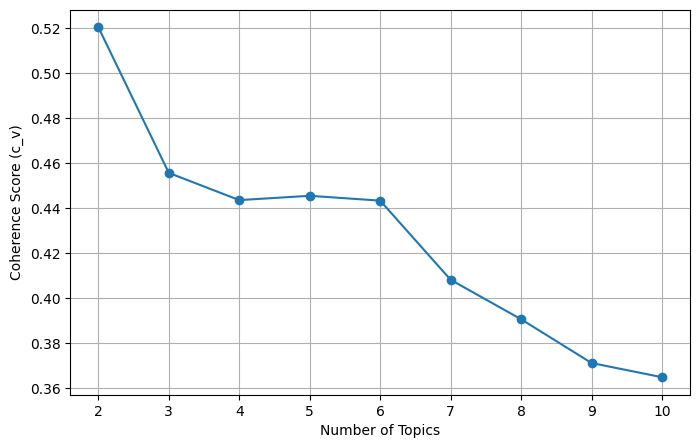

2 0.52
3 0.456
4 0.443
5 0.445
6 0.443
7 0.408
8 0.391
9 0.371
10 0.365


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ============================================
# FIND OPTIMAL NUMBER OF TOPICS
# ============================================

coherence_values = []

topic_range = range(2,11)

for k in topic_range:

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20
    )

    coherence_model = CoherenceModel(
        model=model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_values.append(
        coherence_model.get_coherence()
    )

plt.figure(figsize=(8,5))

plt.plot(
    topic_range,
    coherence_values,
    marker="o"
)

plt.xlabel("Number of Topics")

plt.ylabel("Coherence Score (c_v)")

plt.grid(True)

plt.show()

for k,c in zip(topic_range,coherence_values):

    print(k, round(c,3))

In [ ]:
# ==========================================================
# TEXT PREPROCESSING (VERSION 2.0)
# ==========================================================

import re
import nltk
import spacy

from nltk.corpus import stopwords
from gensim.models import Phrases
from gensim.models.phrases import Phraser

nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))

extra_stopwords = {
    "study","result","results","method","methods","paper","article",
    "using","used","based","show","shows","reported","different",
    "high","low","new","also","could","may","well","one","two",
    "three","first","second","however","therefore","respectively"
}

stop_words.update(extra_stopwords)

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-z\s]', ' ', text)

    doc = nlp(text)

    tokens=[]

    for token in doc:

        lemma = token.lemma_.strip()

        if lemma == "":
            continue

        if token.is_stop:
            continue

        if lemma in stop_words:
            continue

        if len(lemma) < 3:
            continue

        if not lemma.isalpha():
            continue

        tokens.append(lemma)

    return tokens

texts = df["Document"].apply(preprocess).tolist()

print("Number of documents:",len(texts))
print(texts[0][:30])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Number of documents: 192
['feasibility', 'assessment', 'efficient', 'hydrogen', 'freshwater', 'cogeneration', 'system', 'remote', 'mining', 'area', 'base', 'solid', 'oxide', 'electrolysis', 'cell', 'power', 'gas', 'effective', 'pathway', 'level', 'fluctuation', 'renewable', 'energy', 'solid', 'oxide', 'electrolysis', 'cell', 'soec', 'attract', 'attention']


In [ ]:
# ==========================================================
# CREATE BIGRAMS AND TRIGRAMS
# ==========================================================

bigram = Phrases(
    texts,
    min_count=5,
    threshold=10
)

trigram = Phrases(
    bigram[texts],
    threshold=10
)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

texts = [trigram_mod[bigram_mod[doc]] for doc in texts]

print(texts[0][:40])

['feasibility', 'assessment', 'efficient', 'hydrogen', 'freshwater', 'cogeneration', 'system', 'remote', 'mining', 'area', 'base', 'solid', 'oxide', 'electrolysis_cell', 'power', 'gas', 'effective', 'pathway', 'level', 'fluctuation', 'renewable_energy', 'solid', 'oxide', 'electrolysis_cell', 'soec', 'attract', 'attention', 'owe', 'electrolytic', 'efficiency', 'thermal', 'management', 'electrolysis', 'process', 'crucial', 'ensure', 'efficiency', 'efficient', 'hydrogen', 'freshwater']


In [ ]:
# ==========================================================
# CREATE DICTIONARY
# ==========================================================

from gensim import corpora

dictionary = corpora.Dictionary(texts)

dictionary.filter_extremes(
    no_below=3,
    no_above=0.40,
    keep_n=5000
)

corpus = [dictionary.doc2bow(doc) for doc in texts]

print("Vocabulary size:",len(dictionary))
print("Documents:",len(corpus))

Vocabulary size: 1290
Documents: 192


In [ ]:
# ==========================================================
# FINAL LDA MODEL (5 TOPICS)
# ==========================================================

from gensim.models import LdaModel

lda5 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    chunksize=100,
    passes=40,
    iterations=500,
    alpha='auto',
    eta='auto',
    minimum_probability=0.0,
    per_word_topics=True
)

print("="*100)
print("FINAL LDA MODEL (5 TOPICS)")
print("="*100)

for topic_id in range(5):

    print("\n")
    print("="*100)
    print(f"TOPIC {topic_id+1}")
    print("="*100)

    words = lda5.show_topic(topic_id,topn=20)

    for word,weight in words:

        print(f"{word:<35} {weight:.4f}")

FINAL LDA MODEL (5 TOPICS)


TOPIC 1
mec                                 0.0200
model                               0.0196
electrode                           0.0121
microbial                           0.0100
system                              0.0097
cathode                             0.0086
parameter                           0.0080
production                          0.0078
concentration                       0.0073
anode                               0.0073
rate                                0.0070
reactor                             0.0069
condition                           0.0069
control                             0.0068
time                                0.0068
electrochemical                     0.0065
microbial_electrolysis_cell_mec     0.0064
removal                             0.0064
current                             0.0061
substrate                           0.0060


TOPIC 2
catalyst                            0.0179
urea                                0.0141
electro

In [ ]:
# ==========================================================
# COHERENCE OF FINAL MODEL
# ==========================================================

from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda5,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence = coherence_model.get_coherence()

print("="*60)
print(f"Coherence Score (c_v): {coherence:.4f}")
print("="*60)

Coherence Score (c_v): 0.4442


In [ ]:
# ==========================================================
# DOCUMENT DISTRIBUTION BY TOPIC
# ==========================================================

dominant_topics = []

for doc in corpus:

    topics = lda5.get_document_topics(doc)

    dominant = max(topics, key=lambda x: x[1])[0]

    dominant_topics.append(dominant)

df["Dominant_Topic"] = dominant_topics

print(df["Dominant_Topic"].value_counts().sort_index())

Dominant_Topic
0    38
1    83
2     6
3    39
4    26
Name: count, dtype: int64


In [ ]:
# ==========================================================
# MOST REPRESENTATIVE ARTICLES OF EACH TOPIC
# ==========================================================

import pandas as pd

# Obtener probabilidades de cada documento
topic_probs = []

for bow in corpus:

    probs = lda5.get_document_topics(
        bow,
        minimum_probability=0.0
    )

    topic_probs.append([p for _, p in probs])

topic_df = pd.DataFrame(
    topic_probs,
    columns=[f"Topic_{i+1}" for i in range(5)]
)

# Añadir títulos y abstracts
topic_df["Title"] = df["Title"]
topic_df["Abstract"] = df["Abstract"]

# Mostrar los 10 artículos más representativos de cada tópico

for i in range(5):

    print("\n")
    print("="*120)
    print(f"TOPIC {i+1}")
    print("="*120)

    top_docs = topic_df.sort_values(
        by=f"Topic_{i+1}",
        ascending=False
    ).head(10)

    for _, row in top_docs.iterrows():

        print(f"\nProbability: {row[f'Topic_{i+1}']:.3f}")
        print("TITLE:")
        print(row["Title"])



TOPIC 1

Probability: 0.996
TITLE:
Construction of microbial electrodialysis cells equipped with internal proton migration pathways: Enhancement of wastewater treatment, desalination, and hydrogen production

Probability: 0.996
TITLE:
Enabling microbial electrolysis cell scale-up via electrochemistry-, hydrodynamic-, and microbial ecology-informed framework

Probability: 0.995
TITLE:
A Generalized Model for Complex Wastewater Treatment with Simultaneous Bioenergy Production Using the Microbial Electrochemical Cell

Probability: 0.995
TITLE:
Maximizing Bio-Hydrogen Production from an Innovative Microbial Electrolysis Cell Using Artificial Intelligence

Probability: 0.994
TITLE:
Electrocoagulation by solar energy feed for textile wastewater treatment including mechanism and hydrogen production using a novel reactor design with a rotating anode

Probability: 0.993
TITLE:
Real-time monitoring of a microbial electrolysis cell using an electrical equivalent circuit model

Probability: 0.99

In [ ]:
# ==========================================================
# TABLE OF LDA TOPICS
# ==========================================================

import pandas as pd

summary = pd.DataFrame({

    "Topic":[1,2,3,4,5],

    "Main Keywords":[
        "mec, model, microbial, electrode, reactor, parameter, microbial_electrolysis_cell_mec",
        "catalyst, urea, electrocatalyst, uor, water_electrolysis, ammonia",
        "nife_ldh, catalyst, hydrogen_evolution_reaction, electrolyzer, heterojunction",
        "hydrogen, wastewater_treatment, electrolysis, solar, degradation, resource recovery",
        "uor, hydrogen_evolution_reaction, electrocatalyst, bifunctional, kinetics"
    ],

    "Proposed Theme":[
        "Microbial electrolysis systems for wastewater treatment, hydrogen production, and process modeling",
        "Electrocatalyst development for urea-assisted water electrolysis and hydrogen production",
        "Advanced electrocatalytic reaction engineering and catalyst optimization",
        "Integrated electrochemical systems for wastewater treatment, hydrogen production, and resource recovery",
        "High-performance bifunctional electrocatalysts and kinetic enhancement for wastewater-to-hydrogen conversion"
    ]

})

summary

,Topic,Main Keywords,Proposed Theme
0,1,"mec, model, microbial, electrode, reactor, par...",Microbial electrolysis systems for wastewater ...
1,2,"catalyst, urea, electrocatalyst, uor, water_el...",Electrocatalyst development for urea-assisted ...
2,3,"nife_ldh, catalyst, hydrogen_evolution_reactio...",Advanced electrocatalytic reaction engineering...
3,4,"hydrogen, wastewater_treatment, electrolysis, ...",Integrated electrochemical systems for wastewa...
4,5,"uor, hydrogen_evolution_reaction, electrocatal...",High-performance bifunctional electrocatalysts...


In [ ]:
summary.to_excel(
    "LDA_Topics_Summary.xlsx",
    index=False
)

print("LDA topic summary exported successfully.")

LDA topic summary exported successfully.


In [ ]:
# ==========================================================
# DISTRIBUTION OF STUDIES BY TOPIC
# ==========================================================

distribution = pd.DataFrame(
    df["Dominant_Topic"].value_counts().sort_index()
)

distribution.columns=["Number_of_Studies"]

distribution.index = [
    "Topic 1",
    "Topic 2",
    "Topic 3",
    "Topic 4",
    "Topic 5"
]

distribution["Percentage"] = (
    distribution["Number_of_Studies"]/
    distribution["Number_of_Studies"].sum()*100
).round(1)

distribution

,Number_of_Studies,Percentage
Topic 1,38,19.8
Topic 2,83,43.2
Topic 3,6,3.1
Topic 4,39,20.3
Topic 5,26,13.5


In [ ]:
distribution.to_excel(
    "Topic_Distribution.xlsx"
)

print("Topic distribution exported successfully.")

Topic distribution exported successfully.


In [ ]:
# ==========================================================
# EXPORT REPRESENTATIVE PAPERS
# ==========================================================

writer = pd.ExcelWriter(
    "Representative_Articles_by_Topic.xlsx",
    engine="openpyxl"
)

for i in range(5):

    top_docs = topic_df.sort_values(
        by=f"Topic_{i+1}",
        ascending=False
    ).head(10)

    top_docs.to_excel(
        writer,
        sheet_name=f"Topic_{i+1}",
        index=False
    )

writer.close()

print("Representative articles exported successfully.")

Representative articles exported successfully.


In [ ]:
# ==========================================================
# TABLE FOR LDA INTERPRETATION
# ==========================================================

import pandas as pd

table = []

for topic in range(5):

    # Palabras más importantes
    words = lda5.show_topic(topic, topn=8)
    keywords = ", ".join([w for w, _ in words])

    # Tres artículos más representativos
    papers = (
        topic_df
        .sort_values(by=f"Topic_{topic+1}", ascending=False)
        .head(3)["Title"]
        .tolist()
    )

    papers_text = "\n".join([f"• {p}" for p in papers])

    table.append([
        f"Topic {topic+1}",
        keywords,
        papers_text,
        ""
    ])

lda_table = pd.DataFrame(
    table,
    columns=[
        "Topic",
        "Representative keywords",
        "Representative publications",
        "Final thematic interpretation"
    ]
)

lda_table

,Topic,Representative keywords,Representative publications,Final thematic interpretation
0,Topic 1,"mec, model, electrode, microbial, system, cath...",• Construction of microbial electrodialysis ce...,
1,Topic 2,"catalyst, urea, electrocatalyst, electrode, uo...",• Regulating electronic structure by Mn doping...,
2,Topic 3,"nife_ldh, catalyst, phenol, uor, electrolyzer,...",• Enhanced urea oxidization electrocatalysis o...,
3,Topic 4,"system, hydrogen, process, waste, electrolysis...",• An insight into solar thermo-assisted and or...,
4,Topic 5,"uor, urea, hydrogen_evolution_reaction, electr...",• Interfacially engineered Co-MOF@P-SnCoFe lay...,


In [ ]:
lda_table.to_excel(
    "Table_LDA_Interpretation.xlsx",
    index=False
)

print("Table exported successfully.")

Table exported successfully.


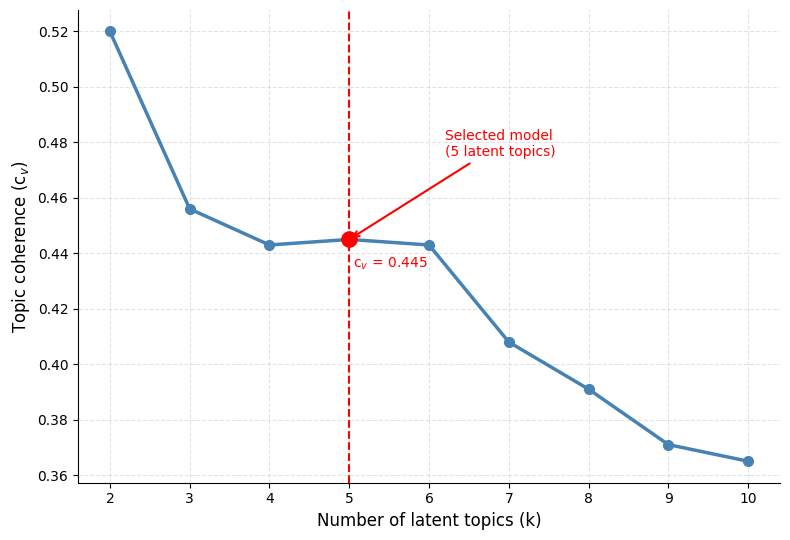

Figure successfully exported.


In [ ]:
# ==========================================================
# FIGURE 3. TOPIC COHERENCE OF THE LDA MODELS
# ==========================================================

import matplotlib.pyplot as plt

# Number of topics evaluated
topics = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Corresponding coherence scores
coherence = [0.520, 0.456, 0.443, 0.445, 0.443, 0.408, 0.391, 0.371, 0.365]

# Selected model
selected_topic = 5
selected_score = 0.445

# ----------------------------------------------------------

plt.figure(figsize=(8,5.5))

# Main curve
plt.plot(
    topics,
    coherence,
    color='steelblue',
    marker='o',
    linewidth=2.5,
    markersize=7
)

# Highlight selected model
plt.scatter(
    selected_topic,
    selected_score,
    color='red',
    s=120,
    zorder=5
)

# Vertical dashed line
plt.axvline(
    x=selected_topic,
    color='red',
    linestyle='--',
    linewidth=1.5
)

# Annotation
plt.annotate(
    'Selected model\n(5 latent topics)',
    xy=(selected_topic, selected_score),
    xytext=(6.2,0.475),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        lw=1.5
    ),
    fontsize=10,
    color='red'
)

# Coherence value
plt.text(
    selected_topic+0.05,
    selected_score-0.010,
    "c$_v$ = 0.445",
    fontsize=10,
    color='red'
)

# Axis labels
plt.xlabel(
    "Number of latent topics (k)",
    fontsize=12
)

plt.ylabel(
    "Topic coherence (c$_v$)",
    fontsize=12
)

# Axis ticks
plt.xticks(topics)

# Grid
plt.grid(
    linestyle='--',
    alpha=0.35
)

# Remove upper and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save figures
plt.savefig(
    "Figure_3_Topic_Coherence.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_3_Topic_Coherence.pdf",
    bbox_inches="tight"
)

plt.show()

print("Figure successfully exported.")

In [ ]:
!pip install pyLDAvis

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [ ]:
# ==========================================================
# PREPARE pyLDAvis VISUALIZATION
# ==========================================================

lda_display = gensimvis.prepare(
    lda5,
    corpus,
    dictionary,
    sort_topics=False
)

pyLDAvis.display(lda_display)

In [ ]:
# ==========================================================
# EXPORT pyLDAvis
# ==========================================================

pyLDAvis.save_html(
    lda_display,
    "Figure_4_pyLDAvis.html"
)

print("pyLDAvis figure exported successfully.")

pyLDAvis figure exported successfully.
